# Мататематички методи за машинско учење 2025/2026
## Домаћи задатак број 4

<div class="alert alert-block alert-danger">
<b>Име и презиме студента:</b>

<b>Број индекса:</b>
    
</div>    

<div class="alert alert-block alert-info">
<b>Упутство за израду и предају домаћег задатака: </b> 
    
    1. Пре почетка израде промените име датотеке у 04Domaci_Ime_Prezime. (убаците своје име и презиме) 
    2. Попуните ћелију испод наслова одговарајућим подацима. 
    1. Употреба ћирилице није обавезна за предају домаћег задатка.
    4. За решавање задатака, уколико је потребно, отворите испод текста задатка додатне ћелије за уписивање текстуалног одговора (Markdown) или програмског кода (Code).
    1. Сва израчунавања, уколико је потребно, вршити у Python-у.
    5. Након завршетка израде решења домаћег Notebook документ сачувати у pdf формату и проследити га наставнику. То можете да урадите или кроз Teams или на мејл адресу jovana.dzunic@elfak.ni.ac.rs

</div> 

In [1]:
import numpy as np
import scipy as sp
import numpy.random as rndm
import matplotlib as mplb
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

**Задатак 1.** Нека је дата матрица $A\in\mathcal{M}_{m\times n}.$ Декомпозиција пуног ранга изражава матрицу $A,$ ${\rm rang}(A)=r\leq\min\{m,n\}$ у облику производа $A=XY,$ $X\in\mathcal{M}_{m\times r},$ $Y\in\mathcal{M}_{r\times n},$ ${\rm rang}(X)={\rm rang}(Y)=r.$ 

**а)** Која од матрица $X$ и $Y$ обезбеђује базу простора врста, а која простора колона матрице $A?$ Како све можемо одредити базне векторе левог и десног језгра матрице $A?$ Због чега ортогоналне базе у овом поступку имају предност?

(5 поена)

**б)** Написати функцију `full_rank_decomp(A, tol=1e-10)` која рачуна `X` и `Y` факторе, али и аутоматски одређује ранг `r` матрице `A`. За декомпозицију користити `scipy.linalg.lu` која враћа `P, L, U`.
Ранг `r` одредити на основу матрице `U` и задате толеранције `tol` (број значајних пивота).
Функција треба да врати три вредности: `X`, `Y` и израчунати ранг `r`.
  
У текстуалној ћелији објаснити како се из `P, L, U` формирају `X` и `Y` и како се дефинише ранг преко матрице `U`.

**Ограничење:** Забрањено коришћење Python петљи.

(10 поена)

**в)** Применити написану функцију `full_rank_decomp(A)` на генерисане матрице из наредне кодне ћелије. Упоредити добијени нумерички ранг са теоријским рангом који је коришћен при генерисању. Објаснити геометријско значење ранга $r$ у контексту димензионалности података (2D и 3D).  

(5 поена)

In [ ]:
bazna_matrica_r1 = np.array([[2., 1]]) # ранг 1
tezine_r1 = np.random.uniform(-10, 10, (100, 1)) 
A_r1 = tezine_r1 @ bazna_matrica_r1

bazna_matrica_r2 = np.array([[1, 0, 1],[0., 1, 1]]) # ранг 2
tezine_r2 = np.random.randn(100, 2) 
A_r2 = tezine_r2 @ bazna_matrica_r2

print(f"Матрица A_r1 генерисана: димензије {A_r1.shape}, теоријски ранг 1")
print(f"Матрица A_r2 генерисана: димензије {A_r2.shape}, теоријски ранг 2")

**г)** **За матрицу `A_r1` (2D тачке):** Нацртати оригиналне тачке и правац који дефинише база простора врста.

**За матрицу `A_r2` (3D тачке):** Користећи 3D приказ, нацртати тачке и раван коју разапињу врсте матрице $A$.

Како чињеница да је $r < n$ омогућава ефикасније складиштење података? 

Израчунати број елемената потребних за чување оригиналне матрице $A$ у односу на матрице $X$ и $Y$.

(4+6+3+2 поена)

**д)** Познато је да су простор врста $\mathcal{R}(A^T)$ и језгро $\mathcal{N}(A)$ ортогонални комплементи.

Користећи функцију `scipy.linalg.null_space`, одредити базу језгра матрице $A_{r2}$. 
Програмски (скаларним производом) потврдити ортогоналност између базе простора врста и базе језгра.

Додати вектор језгра на 3D график. Прокоментарисати његов положај у односу на раван простора врста.

(10 поена)

***

**Задатак 2.** У машинском учењу често користимо LU декомпозицију блок матрица - декомпозиција матрице на производ блок доње троугаоне и блок горње троугаоне матрице.  

Посматрајмо матрицу $ M $ подељену на блокове:
$$
M =
\begin{bmatrix}
A & B \\
C & D
\end{bmatrix},
$$
где је $ A$ квадратна регуларна матрица.

**а)** Показати (матричним множењем) да се $M$ може факторисати као:
$$M =L_BU_B=\begin{bmatrix}
I & 0 \\
CA^{-1} & I
\end{bmatrix}
\begin{bmatrix}
A & B \\
0 & S
\end{bmatrix},
$$
где је $S$ тзв. Шуров комплемент матрице $A$ у односу на $M.$

Експлицитно извести израз за $S,$
$$
S = D - CA^{-1}B.
$$

(5 поена)

**б)** Посматрајмо блок матрицу  
$M = \begin{bmatrix} A & B \\ C & D \end{bmatrix}$  
где је $A$ инвертибилна квадратна матрица.

Имплементирати функцију која за дату блок матрицу израчунава Шуров комплемент матрице $A$ у односу на $M.$ 

(5 поена)

**в)** Показати програмски да важи:  
$$\det(M) = \det(A)\,\det(S).$$
Применити овај концепт на блок матрицу димензија $10 \times 10$ подељену на четири блока $5 \times 5$.

(5 поена)

**г)** Написати функцију `block_lu_step(M, block_size)` која за задату матрицу $M$ и величину горњег левог блока $A:$

- издваја блокове користећи slicing,   
- враћа матрицу $M$ трансформисану у блок горње  троугаону форму $U_B,$ као резултат блок LU процеса.  

Решење мора бити скалабилно за било коју димензију блокова.

(5 поена)

***

**Задатак 3.** Размотримо матрицу која је нумерички "опасна" за LU декомпозицију без пивотирања:
$$ A_\varepsilon = \begin{bmatrix} \varepsilon & 1 \\ 1 & 1 \end{bmatrix},$$
gde je $\varepsilon < \varepsilon_{\text{mach}}.$ 

**а)** Ручно (или симболички) израчунати $L$ и $U=\begin{bmatrix}u_{00}&u_{01}\\u_{10}&u_{11}\end{bmatrix}$ факторе без пивотирања.  
Шта се дешава са елементом $u_{11}$ у аритметици са покретним зарезом? Спроведите експлицитне кораке израчунавања резултата на примеру Numpy низа $$A_\varepsilon = \begin{bmatrix} 10^{-16} & 1 \\ 1 & 1 \end{bmatrix}.$$

(10 поена)

**б)** Користећи `scipy.linalg.lu`, израчунати факторе са пивотирањем.  
Упоредити грешку репродукције $\|A - PLU\|_F$ за овај и претходни поступак. Објаснити зашто је замена редова (пивотирање) неопходна за стабилност код матрица са малим елементима на главној дијагонали. 

(10 поена) 

**в)** У Numpy-у, за $\varepsilon = 10^{-20},$ решити систем  
$$A_\varepsilon x = [1, 2]^T $$  
на два начина:  
- Користећи сопствену имплементацију експлицитних корака без пивотирања.  
- Користећи `scipy.linalg.solve` (која користи пивотирање).

(10 поена)

**г)** Упоредити релативну грешку  
$$\|A x_{\text{izračunato}} - b\|.$$
Повезати резултат са задатком о катастрофалном поништавању са претходног домаћег.  

(5 поена)

***

**Задатак 4.**
У пракси се често сусрећемо са матрицама које су регуларне, али су осетљиве – мале промене у подацима доводе до огромних грешака у решењу. 

**а)** Користећи функцију `np.vander`, креирати Вандермондову матрицу $V$ димензија $10 \times 10$ над низом од 10 еквидистантних тачака из интервала $[1, 2]$. 
1. Извршити LU декомпозицију $PV = LU$. Приказати дијагоналне елементе (пивоте) матрице $U$. Шта примећујете код последњих неколико пивота?
2. Дефинисати тачно решење $x_{true} = \text{np.ones}(10)$ и израчунати десну страну $b = V x_{true}$.
3. Решити систем $Vx = b$ помоћу `np.linalg.solve`. Израчунати Фробенијусову норму грешке $\|x - x_{true}\|_F$.

(5 поена)

**б)** Симулирајмо малу грешку у мерењу података (шум). 
1. Креирати вектор слободних чланова са додатком белог шума $b_{noise} = b + \epsilon$, где је $\epsilon$ насумичан вектор јако мале норме (нпр. $10^{-8}$).
2. Поново решити систем $Vx_{noise} = b_{noise}$ и израчунати грешку $\|x_{noise} - x_{true}\|_F$.
3. Упоредити норму шума $\|\epsilon\|_F$ и норму грешке у решењу. Колико пута се грешка увећала?

(10 поена)

**в)** Уводимо регуларизовану матрицу $V_{\lambda} = V + \lambda I.$
1. Написати функцију која за низ вредности $\lambda = [10^{-1}, 10^{-3}, 10^{-6}, 10^{-9}, 0]$ израчунава LU декомпозицију и решава систем са шумом $(V + \lambda I)x_{\lambda} = b_{noise}$.
2. За свако $\lambda$ израчунати:
   - Вредност најмањег пивота матрице $U$ (по апсолутној вредности).
   - Грешку решења $\|x_{\lambda} - x_{true}\|_F$.
3. Нацртати два графика (у логаритамској скали): 
   - Зависност најмањег пивота од $\lambda$.
   - Зависност грешке решења од $\lambda$.
   
(10 поена)

**г)**  
На основу добијених графика објаснити шта се дешава са стабилношћу система када је $\lambda=0$. Како додавање малог $\lambda$ утиче на вредност пивота и зашто то спречава експлозију грешке? Повезати ово са стабилизацијом нумеричких израчунавања кроз спречавање дељења јако малим бројевима.

(5 поена)

***

**Задатак 5.** У претходном домаћем сте користили K-means за компресију слике. Сада ћемо то упоредити са апроксимацијом ниског ранга која се ослања на декомпозицију пуног ранга матрице слике.

Активирати доњи код којим се учитава слика (grayscale) као матрица $A.$  
И дефинише функција којом се израчунава најбоља апроксимација помоћу декомпозиције пуног ранга $A_k = X_k Y_k$ на основу задатог параметра $k.$ Параметар $k$ је унапред дефинисан ранг матрица фактора $X_k$ и $Y_k.$

In [3]:
import scipy.datasets as scd

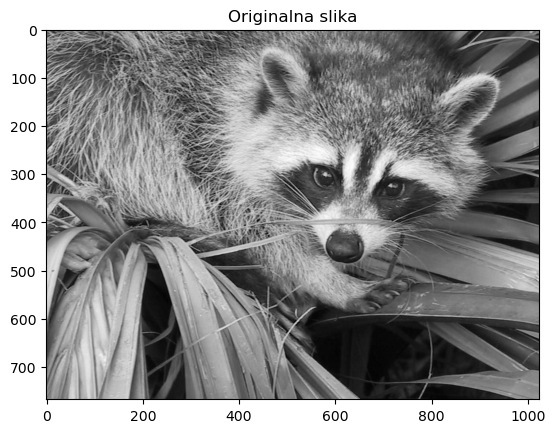

In [4]:
rakun=scd.face()
sk_vredn=rakun/255
A = sk_vredn @ [0.2126, 0.7152, 0.0722]
A.shape
plt.imshow(A, cmap="gray");
plt.title("Originalna slika");

In [ ]:
def naj_aproks(A,k):
    X,S,Y=sp.linalg.svd(A)
    A_k=(X*S)[:,:k]@Y[:k,:] #деккомпозиција пуног ранга апроксимационе матрице A_k
    return(A_k)

**а)** Нацртати график зависности грешке апроксимације  
$$\|A - A_k\|_F$$  
од ранга $k$ (за $k\in\{1, 5, 10, 20, 50\}$).  

(5 поена)

**б)** Упоредити број параметара потребан за чување слике код:
- K-means сегментације (из прошлог домаћег),
- Апроксимације ниског ранга $A_k=X_k Y_k.$

Који метод боље чува текстуру, а који регије (боје)?  Можете да проверите резултате функционисања оба поступка на додатним сликама према свом избору. Бирајте неке које су природнијег садржаја наспрам слика са једним објектом у фокусу.

(10 поена)

***

**Задатак 6.** У обради слика, суперпиксели представљају групе пиксела које замењују класичну правоугаону мрежу. Овде ћемо слику посматрати као велику блок матрицу и спровести основну суперпиксел декомпозицију користећи векторизацију.

**а)** 
Написати функцију `image_to_blocks(img, k)` која трансформише grayscale слику димензија $H \times W$ у 4D низ димензија $(H/k, W/k, k, k)$, где сваки елемент $(i, j)$ представља блок величине $k \times k$. Такође, написати инверзну функцију `blocks_to_image(blocks)` која враћа блокове у оригинални 2D формат користећи `np.block` или паметно препакивање. 

(Напомена: Користити слику ракуна и исећи је тако да су димензије дељиве са $k=10$.)  

(10 поена)

**б)**  За сваки блок израчунати средњи интензитет пиксела и $(x, y)$ координате центра блока у оригиналној слици. Резултат треба да буде матрица карактеристика $F$ димензија $(N_{blocks} \times 3)$. Све прорачуне извршити векторизовано (користећи `np.mean` по одговарајућим осама).  

(10 поена)

**в)**  Применити K-means кластеризацију над матрицом $F$. Реконструисати слику тако што ће сваки блок бити замењен средњим интензитетом који дефинише центар припадајућег кластера. Приказати резултат сегментације.  

(10 поена)

***